# FDCS-Net V4: True Hybrid Architecture with Attention Fusion

## Key Improvements over V3:
1. **CNN-based branches** for Color Stability and FFT (not simple Lambda→Dense)
2. **Attention-based fusion** (not naive concatenation)
3. **Auxiliary supervision** to force branches to learn meaningful features
4. **3-stage training**: backbone-only → branches-only → full end-to-end
5. **L2-normalized** 256-dim features from all branches to prevent dominance
6. **Full spatial FFT maps** preserved (no radial collapse)

### Training Strategy:
- **Stage 1**: Train EfficientNet spatial branch alone (90% frozen)
- **Stage 2**: Freeze EfficientNet, train Color + FFT CNN branches with auxiliary losses
- **Stage 3**: Unfreeze all, end-to-end with attention fusion + auxiliary losses

The cell below already performs evaluation and generates the confusion matrix. Please run it to see the results.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Imports

In [ ]:
import os, shutil, time, gc
import numpy as np
import tensorflow as tf
import keras
from tensorflow.keras import layers, Model, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Enable Mixed Precision

In [ ]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f'Compute dtype: {tf.keras.mixed_precision.global_policy().compute_dtype}')
print(f'Variable dtype: {tf.keras.mixed_precision.global_policy().variable_dtype}')
print('✅ Mixed precision enabled')

Compute dtype: float16
Variable dtype: float32
✅ Mixed precision enabled


## 3. Configuration

In [ ]:
IMG_SIZE = 256
COLOR_MAP_SIZE = 128
BATCH_SIZE = 32
LEARNING_RATE = 1.5e-4
VALIDATION_SPLIT = 0.2
LABEL_SMOOTHING = 0.05
WEIGHT_DECAY = 1e-4
NOISE_SIGMA = 0.01
QUANT_BITS = 4  # 16 levels per channel
FEATURE_DIM = 256  # All branches output this dimension

# Paths
DRIVE_TRAIN_DIR = '/content/drive/MyDrive/dataset/ddata/train'
DRIVE_TEST_DIR  = '/content/drive/MyDrive/dataset/ddata/test'
LOCAL_TRAIN_DIR = '/content/local_data/train'
LOCAL_TEST_DIR  = '/content/local_data/test'

# 3-Stage training config
STAGE1_EPOCHS = 12
STAGE1_FREEZE_RATIO = 0.90
STAGE2_EPOCHS = 10
STAGE3_EPOCHS = 10
STAGE3_FREEZE_RATIO = 0.70

print(f'Feature dimension: {FEATURE_DIM}')
print(f'Stage 1: {STAGE1_EPOCHS} epochs (EfficientNet only)')
print(f'Stage 2: {STAGE2_EPOCHS} epochs (Color+FFT branches)')
print(f'Stage 3: {STAGE3_EPOCHS} epochs (Full end-to-end)')

Feature dimension: 256
Stage 1: 12 epochs (EfficientNet only)
Stage 2: 10 epochs (Color+FFT branches)
Stage 3: 10 epochs (Full end-to-end)


## 4. Copy Dataset to Local SSD

In [ ]:
def copy_to_local(src, dst):
    if os.path.exists(dst):
        print(f'  Already exists: {dst}')
        return
    print(f'  Copying {src} -> {dst} ...')
    start = time.time()
    shutil.copytree(src, dst)
    elapsed = time.time() - start
    n_files = sum(len(f) for _, _, f in os.walk(dst))
    print(f'  Done: {n_files} files in {elapsed:.1f}s')

print('📦 Copying dataset to local SSD...')
copy_to_local(DRIVE_TRAIN_DIR, LOCAL_TRAIN_DIR)
copy_to_local(DRIVE_TEST_DIR, LOCAL_TEST_DIR)
print('✅ Dataset on local SSD.')

TRAIN_DIR = LOCAL_TRAIN_DIR
TEST_DIR = LOCAL_TEST_DIR

📦 Copying dataset to local SSD...
  Copying /content/drive/MyDrive/dataset/ddata/train -> /content/local_data/train ...
  Done: 8211 files in 243.5s
  Copying /content/drive/MyDrive/dataset/ddata/test -> /content/local_data/test ...
  Done: 2218 files in 76.7s
✅ Dataset on local SSD.


## 5. Data Pipeline

In [ ]:
def parse_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def build_dataset(directory, is_training=True, validation_split=0.2, subset='training'):
    file_paths, labels = [], []
    for class_idx, class_name in enumerate(['real', 'ai']):
        class_path = os.path.join(directory, class_name)
        if os.path.exists(class_path):
            for fname in sorted(os.listdir(class_path)):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    file_paths.append(os.path.join(class_path, fname))
                    labels.append(float(class_idx))
    file_paths = np.array(file_paths)
    labels = np.array(labels, dtype=np.float32)
    np.random.seed(42)
    indices = np.random.permutation(len(file_paths))
    file_paths, labels = file_paths[indices], labels[indices]
    split_idx = int(len(file_paths) * (1 - validation_split))
    if subset == 'training':
        file_paths, labels = file_paths[:split_idx], labels[:split_idx]
    else:
        file_paths, labels = file_paths[split_idx:], labels[split_idx:]
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    cache_path = '/content/cache_train' if is_training else '/content/cache_val'
    dataset = dataset.cache(cache_path)
    if is_training:
        dataset = dataset.shuffle(buffer_size=min(2000, len(file_paths)))
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.repeat()
    else:
        dataset = dataset.repeat()
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset, len(file_paths)

train_dataset, n_train = build_dataset(TRAIN_DIR, True, VALIDATION_SPLIT, 'training')
val_dataset, n_val = build_dataset(TRAIN_DIR, False, VALIDATION_SPLIT, 'validation')
steps_per_epoch = n_train // BATCH_SIZE
validation_steps = n_val // BATCH_SIZE

print(f'\n✅ Pipeline built')
print(f'  Train: {n_train} samples, {steps_per_epoch} steps/epoch')
print(f'  Val:   {n_val} samples, {validation_steps} val steps')

print('\n⏱️ Warming cache...')
for i, _ in enumerate(train_dataset):
    if i >= steps_per_epoch: break
for i, _ in enumerate(val_dataset):
    if i >= validation_steps: break
print('✅ Cache warmed.')


✅ Pipeline built
  Train: 6568 samples, 205 steps/epoch
  Val:   1643 samples, 51 val steps

⏱️ Warming cache...
✅ Cache warmed.


## 6. Feature Extraction Functions

**Key difference from V3**: Both branches now produce full spatial feature maps
(image-like tensors) that are processed by CNNs, not collapsed to simple vectors.

In [ ]:
@keras.saving.register_keras_serializable()
def compute_fft_magnitude_map(images):
    """Compute 2D FFT magnitude spectrum as a spatial image for CNN processing."""
    original_dtype = images.dtype
    images_f32 = tf.cast(images, tf.float32)
    color_weights = tf.constant([0.2989, 0.5870, 0.1140], dtype=tf.float32)
    gray = tf.reduce_sum(images_f32 * color_weights, axis=-1)
    fft = tf.signal.fft2d(tf.cast(gray, tf.complex64))
    fft_shifted = tf.signal.fftshift(fft, axes=[1, 2])
    magnitude = tf.abs(fft_shifted)
    log_mag = tf.math.log(magnitude + 1.0)
    batch_min = tf.reduce_min(log_mag, axis=[1, 2], keepdims=True)
    batch_max = tf.reduce_max(log_mag, axis=[1, 2], keepdims=True)
    log_mag = (log_mag - batch_min) / (batch_max - batch_min + 1e-8)
    log_mag = tf.expand_dims(log_mag, -1)
    log_mag = tf.image.resize(log_mag, [COLOR_MAP_SIZE, COLOR_MAP_SIZE])
    log_mag = tf.repeat(log_mag, 3, axis=-1)
    return tf.cast(log_mag, original_dtype)

@keras.saving.register_keras_serializable()
def compute_color_stability_map(images):
    """Compute perturbation-based color difference map for CNN processing."""
    original_dtype = images.dtype
    images_f32 = tf.cast(images, tf.float32)
    noise = tf.random.normal(tf.shape(images_f32), mean=0.0, stddev=NOISE_SIGMA, dtype=tf.float32)
    noisy = tf.clip_by_value(images_f32 + noise, 0.0, 1.0)
    num_levels = tf.constant(2.0 ** QUANT_BITS, dtype=tf.float32)
    quantized = tf.round(noisy * (num_levels - 1.0)) / (num_levels - 1.0)
    avg_kernel = tf.ones([3, 3, 3, 1], dtype=tf.float32) / 9.0
    restored = tf.nn.depthwise_conv2d(quantized, avg_kernel, [1, 1, 1, 1], 'SAME')
    diff = tf.abs(images_f32 - restored)
    batch_min = tf.reduce_min(diff, axis=[1, 2, 3], keepdims=True)
    batch_max = tf.reduce_max(diff, axis=[1, 2, 3], keepdims=True)
    diff = (diff - batch_min) / (batch_max - batch_min + 1e-8)
    result = tf.image.resize(diff, [COLOR_MAP_SIZE, COLOR_MAP_SIZE])
    return tf.cast(result, original_dtype)

# Test
dummy = tf.random.uniform((2, 256, 256, 3))
print(f'FFT magnitude map: {compute_fft_magnitude_map(dummy).shape}')
print(f'Color stability map: {compute_color_stability_map(dummy).shape}')
dummy_f16 = tf.cast(dummy, tf.float16)
fft_out = compute_fft_magnitude_map(dummy_f16)
cs_out = compute_color_stability_map(dummy_f16)
print(f'Float16 FFT: shape={fft_out.shape}, nan={tf.reduce_any(tf.math.is_nan(fft_out)).numpy()}')
print(f'Float16 CS:  shape={cs_out.shape}, nan={tf.reduce_any(tf.math.is_nan(cs_out)).numpy()}')

FFT magnitude map: (2, 128, 128, 3)
Color stability map: (2, 128, 128, 3)
Float16 FFT: shape=(2, 128, 128, 3), nan=False
Float16 CS:  shape=(2, 128, 128, 3), nan=False


## 7. Model Architecture

- **Spatial branch**: EfficientNetB0 → GAP → Dense(256) → BN → ReLU
- **Color branch**: Lambda(color_map) → Conv2D(32)→ReLU→MaxPool → Conv2D(64)→ReLU→MaxPool → GAP → Dense(256) → BN
- **FFT branch**: Lambda(fft_map) → Conv2D(32)→ReLU→MaxPool → Conv2D(64)→ReLU→MaxPool → GAP → Dense(256) → BN
- **Fusion**: L2-normalize all → Concat → Dense(3)+Softmax → weighted sum
- **Auxiliary outputs**: Each branch has its own classifier head

In [ ]:
def preprocess_fn(x):
    return tf.keras.applications.efficientnet.preprocess_input(x * 255.0)

def l2_norm_fn(x):
    return tf.cast(tf.math.l2_normalize(tf.cast(x, tf.float32), axis=-1), x.dtype)

def stack_fn(x):
    return tf.stack(x, axis=1)

def expand_dims_fn(x):
    return tf.expand_dims(x, -1)

def cast_fn(x):
    return tf.cast(x, tf.float32)

def weighted_sum_fn(inputs):
    return tf.reduce_sum(inputs[0] * inputs[1], axis=1)

In [ ]:
def build_cnn_branch(input_shape, name_prefix):
    """Build a CNN branch for processing feature maps."""
    inp = layers.Input(shape=input_shape, name=f'{name_prefix}_input')
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name=f'{name_prefix}_conv1')(inp)
    x = layers.ReLU(name=f'{name_prefix}_relu1')(x)
    x = layers.MaxPooling2D((2,2), name=f'{name_prefix}_pool1')(x)
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name=f'{name_prefix}_conv2')(x)
    x = layers.ReLU(name=f'{name_prefix}_relu2')(x)
    x = layers.MaxPooling2D((2,2), name=f'{name_prefix}_pool2')(x)
    x = layers.GlobalAveragePooling2D(name=f'{name_prefix}_gap')(x)
    x = layers.Dense(FEATURE_DIM, kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name=f'{name_prefix}_dense')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn')(x)
    return Model(inputs=inp, outputs=x, name=f'{name_prefix}_branch')


def build_fdcsnet_v4(freeze_ratio=0.90, enable_aux=True, freeze_backbone_completely=False):

    raw_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='raw_input')

    # === Branch 1: EfficientNetB0 (Spatial) ===
    img_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='img_branch_input')

    x_img = layers.Lambda(
        preprocess_fn,
        output_shape=(IMG_SIZE, IMG_SIZE, 3),
        name='efficientnet_preprocess'
    )(img_in)

    backbone = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))

    if freeze_backbone_completely:
        for layer in backbone.layers:
            layer.trainable = False
    else:
        freeze_until = int(len(backbone.layers) * freeze_ratio)
        for i, layer in enumerate(backbone.layers):
            layer.trainable = (i >= freeze_until)

    x_img = backbone(x_img)
    x_img = layers.GlobalAveragePooling2D(name='img_gap')(x_img)
    x_img = layers.Dense(FEATURE_DIM, kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name='img_dense')(x_img)
    x_img = layers.BatchNormalization(name='img_bn')(x_img)
    x_img = layers.ReLU(name='img_relu')(x_img)

    image_branch = Model(inputs=img_in, outputs=x_img, name='SpatialBranch')
    F_spatial = image_branch(raw_input)

    # === Branch 2: Color Stability ===
    color_map = layers.Lambda(
        compute_color_stability_map,
        output_shape=(COLOR_MAP_SIZE, COLOR_MAP_SIZE, 3),
        name='lambda_color_stability'
    )(raw_input)

    color_branch = build_cnn_branch((COLOR_MAP_SIZE, COLOR_MAP_SIZE, 3), 'color')
    F_color = color_branch(color_map)

    # === Branch 3: FFT Magnitude ===
    fft_map = layers.Lambda(
        compute_fft_magnitude_map,
        output_shape=(COLOR_MAP_SIZE, COLOR_MAP_SIZE, 3),
        name='lambda_fft_magnitude'
    )(raw_input)

    freq_branch = build_cnn_branch((COLOR_MAP_SIZE, COLOR_MAP_SIZE, 3), 'freq')
    F_freq = freq_branch(fft_map)

    # === L2 Normalization ===
    F_spatial_norm = layers.Lambda(l2_norm_fn, output_shape=lambda s: s, name='norm_spatial')(F_spatial)
    F_color_norm = layers.Lambda(l2_norm_fn, output_shape=lambda s: s, name='norm_color')(F_color)
    F_freq_norm = layers.Lambda(l2_norm_fn, output_shape=lambda s: s, name='norm_freq')(F_freq)

    # === Attention Fusion ===
    stacked = layers.Lambda(stack_fn, name='stack_features')(
        [F_spatial_norm, F_color_norm, F_freq_norm]
    )

    concat_for_attn = layers.Concatenate(name='concat_for_attn')(
        [F_spatial_norm, F_color_norm, F_freq_norm]
    )

    attn_weights = layers.Dense(
        3,
        activation='softmax',
        dtype='float32',
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name='attention_weights'
    )(concat_for_attn)

    attn_weights_expanded = layers.Lambda(
        expand_dims_fn,
        name='expand_attn_weights'
    )(attn_weights)

    stacked_f32 = layers.Lambda(
        cast_fn,
        name='cast_stacked'
    )(stacked)

    F_final = layers.Lambda(
        weighted_sum_fn,
        name='weighted_sum'
    )([stacked_f32, attn_weights_expanded])

    # === Head ===
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name='head_dense1')(F_final)
    x = layers.ReLU(name='head_relu1')(x)
    x = layers.Dropout(0.3, name='head_drop1')(x)

    main_output = layers.Dense(1, activation='sigmoid', dtype='float32', name='main_output')(x)

    outputs = [main_output]

    if enable_aux:
        ca = layers.Dense(128, kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name='color_aux_dense')(F_color_norm)
        ca = layers.ReLU(name='color_aux_relu')(ca)
        ca = layers.Dropout(0.3, name='color_aux_drop')(ca)
        color_output = layers.Dense(1, activation='sigmoid', dtype='float32', name='color_output')(ca)

        fa = layers.Dense(128, kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name='freq_aux_dense')(F_freq_norm)
        fa = layers.ReLU(name='freq_aux_relu')(fa)
        fa = layers.Dropout(0.3, name='freq_aux_drop')(fa)
        freq_output = layers.Dense(1, activation='sigmoid', dtype='float32', name='freq_output')(fa)

        outputs = [main_output, color_output, freq_output]

    model = Model(inputs=raw_input, outputs=outputs, name='FDCSNet_v4')

    return model, backbone, image_branch, color_branch, freq_branch

## 8. Multi-Output Data Adapter & Compile Helpers

In [ ]:
def adapt_dataset_for_multi_output(dataset):
    def _adapt(image, label):
        return image, {'main_output': label, 'color_output': label, 'freq_output': label}
    return dataset.map(_adapt, num_parallel_calls=tf.data.AUTOTUNE)

train_multi = adapt_dataset_for_multi_output(train_dataset)
val_multi = adapt_dataset_for_multi_output(val_dataset)

def compile_model_single(model, lr=LEARNING_RATE):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy', keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'), keras.metrics.AUC(name='auc')]
    )

def compile_model_multi(model, lr=LEARNING_RATE):
    loss_fn = keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={'main_output': loss_fn, 'color_output': loss_fn, 'freq_output': loss_fn},
        loss_weights={'main_output': 1.0, 'color_output': 0.3, 'freq_output': 0.3},
        metrics={'main_output': ['accuracy', keras.metrics.AUC(name='auc')],
                 'color_output': ['accuracy'], 'freq_output': ['accuracy']}
    )

def get_callbacks():
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]

## 9. STAGE 1: Train EfficientNet Spatial Branch Alone
Color and FFT branches are frozen. Only the spatial (EfficientNet) branch learns.

In [ ]:
print('\n' + '='*70)
print('STAGE 1: Train EfficientNet spatial branch alone')
print('='*70)

model, backbone, image_branch, color_branch, freq_branch = build_fdcsnet_v4(
    freeze_ratio=STAGE1_FREEZE_RATIO, enable_aux=False, freeze_backbone_completely=False
)
color_branch.trainable = False
freq_branch.trainable = False
compile_model_single(model, lr=LEARNING_RATE)

dummy_out = model(tf.random.uniform((2, IMG_SIZE, IMG_SIZE, 3)), training=False)
print(f'✅ Model output: {dummy_out.shape}, dtype: {dummy_out.dtype}')
print(f'   NaN: {tf.reduce_any(tf.math.is_nan(dummy_out)).numpy()}')

t0 = time.time()
history1 = model.fit(
    train_dataset, steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset, validation_steps=validation_steps,
    epochs=STAGE1_EPOCHS, callbacks=get_callbacks(), verbose=1
)

stage1_time = time.time() - t0
print(f'\n✅ Stage 1 done: {len(history1.history["loss"])} epochs in {stage1_time/60:.1f} min')
model.save_weights('/content/drive/MyDrive/model utilities/stage1_weights.weights.h5')
print('Stage 1 weights saved.')


STAGE 1: Train EfficientNet spatial branch alone
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ Model output: (2, 1), dtype: <dtype: 'float32'>
   NaN: False
Epoch 1/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 154s 335ms/step - accuracy: 0.7398 - auc: 0.8145 - loss: 0.6369 - precision: 0.7554 - recall: 0.7150 - val_accuracy: 0.7837 - val_auc: 0.9358 - val_loss: 0.5445 - val_precision: 0.7123 - val_recall: 0.9726 - learning_rate: 1.5000e-04
Epoch 2/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 43s 211ms/step - accuracy: 0.8608 - auc: 0.9336 - loss: 0.4393 - precision: 0.8584 - recall: 0.8669 - val_accuracy: 0.8854 - val_auc: 0.9663 - val_loss: 0.3907 - val_precision: 0.9394 - val_recall: 0.8310 - learning_rate: 1.5000e-04
Epoch 3/12
205/205 ━━━━━━━━━━━━━━━━━━━━ 43s 210ms/step - accuracy: 0.9117 - auc: 0.9670 - loss: 0.3520 - precision: 0.9149 - recall: 0.9090 - val_accuracy: 0.8995 - val_auc: 0.9680 - val_loss: 0.3550 - val_precision: 0.9142 - val_recall: 0.8881 - learning_rate: 1.5000e-04
Epoch 4/12
205/

## 10. STAGE 2: Train Color + FFT CNN Branches
EfficientNet is completely frozen. Color and FFT branches train with auxiliary supervision.

In [ ]:
print('\n' + '='*70)
print('STAGE 2: Train Color + FFT branches (EfficientNet frozen)')
print('='*70)

tf.keras.backend.clear_session()
gc.collect()

model, backbone, image_branch, color_branch, freq_branch = build_fdcsnet_v4(
    freeze_ratio=1.0, enable_aux=True, freeze_backbone_completely=True
)
# Load weights from Stage 1 using the correct filename and removing by_name=True
model.load_weights('/content/drive/MyDrive/model utilities/stage1_weights.weights.h5', skip_mismatch=True)
image_branch.trainable = False
color_branch.trainable = True
freq_branch.trainable = True
compile_model_multi(model, lr=LEARNING_RATE)

t0 = time.time()
history2 = model.fit(
    train_multi, steps_per_epoch=steps_per_epoch,
    validation_data=val_multi, validation_steps=validation_steps,
    epochs=STAGE2_EPOCHS, callbacks=get_callbacks(),
    # Removed class_weight as it's not supported for multi-output models
    verbose=1
)
stage2_time = time.time() - t0
print(f'\n✅ Stage 2 done: {len(history2.history["loss"])} epochs in {stage2_time/60:.1f} min')
model.save_weights('/content/drive/MyDrive/model utilities/stage2_weights.weights.h5')
print('Stage 2 weights saved.')


STAGE 2: Train Color + FFT branches (EfficientNet frozen)
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:643: UserWarning: A total of 5 objects could not be loaded. Example error message for object <Dense name=color_aux_dense, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(256, 128), Received: value.shape=(128, 1). Target variable: <Variable path=color_aux_dense/kernel, shape=(256, 128), dtype=float32, value=[[-0.01450324 -0.0526312   0.02451912 ...  0.05148247 -0.01175258
   0.11073399]
 [ 0.02099168  0.12383437  0.09710434 ... -0.07974371  0.06853437
   0.119454  ]
 [-0.08743054 -0.07230803  0.10513046 ... -0.10698065 -0.03650284
  -0.00876498]
 ...
 [-0.02137911 -0.12101489 -0.05048153 ... -0.08761495  0.022376
   0.10380551]
 [-0.06593883  0.08093068 -0.02599022 ...  0.00285029  0.03963196
  -0.10319161]
 [ 0.06474394  0.00298434 -0.03847131 ... -0.12076735  0.1084989
  -0.10870454]]>

List of objects that could not be loaded:

205/205 ━━━━━━━━━━━━━━━━━━━━ 109s 298ms/step - color_output_accuracy: 0.5416 - color_output_loss: 0.6881 - freq_output_accuracy: 0.5671 - freq_output_loss: 0.6845 - loss: 0.8161 - main_output_accuracy: 0.9694 - main_output_auc: 0.9949 - main_output_loss: 0.3307 - val_color_output_accuracy: 0.5196 - val_color_output_loss: 0.6905 - val_freq_output_accuracy: 0.5147 - val_freq_output_loss: 0.6987 - val_loss: 0.7487 - val_main_output_accuracy: 0.9314 - val_main_output_auc: 0.9842 - val_main_output_loss: 0.2627 - learning_rate: 1.5000e-04
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 73s 357ms/step - color_output_accuracy: 0.5681 - color_output_loss: 0.6816 - freq_output_accuracy: 0.5634 - freq_output_loss: 0.6831 - loss: 0.6342 - main_output_accuracy: 0.9869 - main_output_auc: 0.9989 - main_output_loss: 0.1592 - val_color_output_accuracy: 0.5349 - val_color_output_loss: 0.6890 - val_freq_output_accuracy: 0.4969 - val_freq_output_loss: 0.6920 - val_loss: 0.7303 - val_main_output_accuracy: 0.9314 -

## 11. STAGE 3: Full End-to-End with Attention Fusion
All branches trainable. Attention fusion learns adaptive weighting. Auxiliary losses active.

In [ ]:
print('\n' + '='*70)
print('STAGE 3: Full end-to-end training with attention fusion')
print('='*70)

tf.keras.backend.clear_session()
gc.collect()

model, backbone, image_branch, color_branch, freq_branch = build_fdcsnet_v4(
    freeze_ratio=STAGE3_FREEZE_RATIO, enable_aux=True, freeze_backbone_completely=False
)
model.load_weights('/content/drive/MyDrive/model utilities/stage2_weights.weights.h5', skip_mismatch=True)
image_branch.trainable = True
color_branch.trainable = True
freq_branch.trainable = True
freeze_until = int(len(backbone.layers) * STAGE3_FREEZE_RATIO)
for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= freeze_until)
compile_model_multi(model, lr=LEARNING_RATE * 0.3)

t0 = time.time()
history3 = model.fit(
    train_multi, steps_per_epoch=steps_per_epoch,
    validation_data=val_multi, validation_steps=validation_steps,
    epochs=STAGE3_EPOCHS, callbacks=get_callbacks(),
    # Removed class_weight as it's not supported for multi-output models
    verbose=1
)
stage3_time = time.time() - t0
total_time = stage1_time + stage2_time + stage3_time
print(f'\n✅ Stage 3 done: {len(history3.history["loss"])} epochs in {stage3_time/60:.1f} min')
print(f'⏱️ Total training: {total_time/60:.1f} min')
model.save_weights('/content/drive/MyDrive/model utilities/fdcsnet_v4.weights.h5')
print('Final model weights saved.')


STAGE 3: Full end-to-end training with attention fusion
Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 120s 314ms/step - color_output_accuracy: 0.5875 - color_output_loss: 0.6724 - freq_output_accuracy: 0.5782 - freq_output_loss: 0.6739 - loss: 0.7583 - main_output_accuracy: 0.9174 - main_output_auc: 0.9728 - main_output_loss: 0.2788 - val_color_output_accuracy: 0.5018 - val_color_output_loss: 0.7024 - val_freq_output_accuracy: 0.5803 - val_freq_output_loss: 0.6753 - val_loss: 0.8425 - val_main_output_accuracy: 0.8848 - val_main_output_auc: 0.9746 - val_main_output_loss: 0.3546 - learning_rate: 4.5000e-05
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 51s 249ms/step - color_output_accuracy: 0.5916 - color_output_loss: 0.6713 - freq_output_accuracy: 0.5840 - freq_output_loss: 0.6734 - loss: 0.6979 - main_output_accuracy: 0.9471 - main_output_auc: 0.9884 - main_output_loss: 0.2207 - val_color_output_accuracy: 0.4975 - val_color_output_loss: 0.7063 - val_freq_output_accuracy: 0.4957 - val_freq_output_

## 12. Training Curves

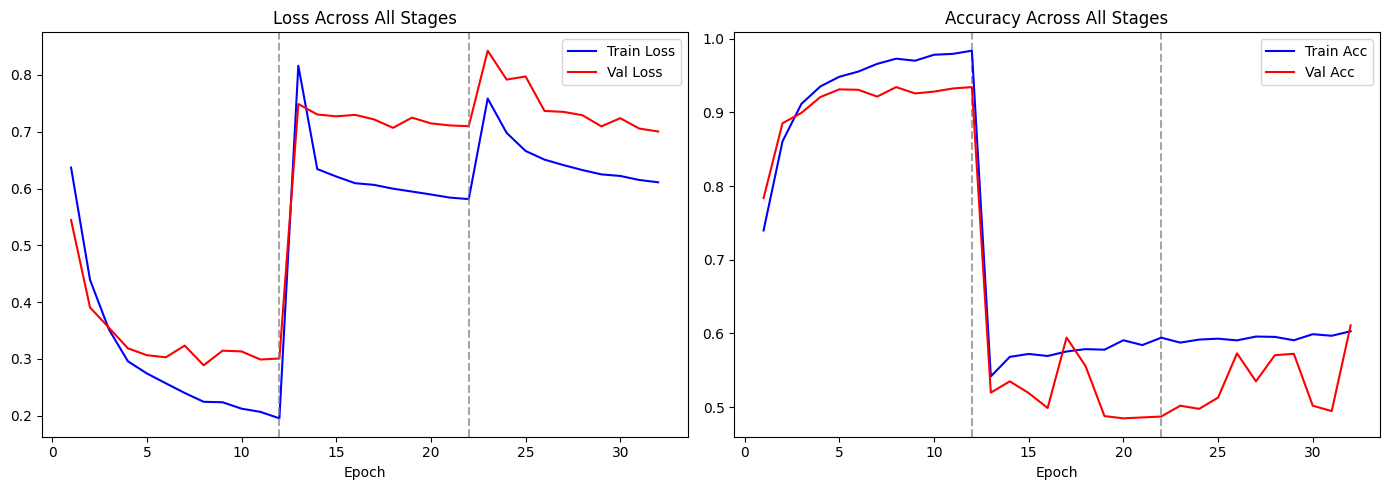

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_loss, all_val_loss = [], []
for hist in [history1, history2, history3]:
    all_loss.extend(hist.history['loss'])
    all_val_loss.extend(hist.history['val_loss'])

epochs_range = range(1, len(all_loss) + 1)
axes[0].plot(epochs_range, all_loss, 'b-', label='Train Loss')
axes[0].plot(epochs_range, all_val_loss, 'r-', label='Val Loss')
axes[0].set_title('Loss Across All Stages')
axes[0].legend()
axes[0].set_xlabel('Epoch')

# Mark stage boundaries
s1_end = len(history1.history['loss'])
s2_end = s1_end + len(history2.history['loss'])
for ax in axes:
    ax.axvline(x=s1_end, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(x=s2_end, color='gray', linestyle='--', alpha=0.7)

# Accuracy plot (use first accuracy key found)
all_acc, all_val_acc = [], []
for hist in [history1, history2, history3]:
    acc_keys = [k for k in hist.history if 'accuracy' in k and 'val' not in k]
    val_acc_keys = [k for k in hist.history if 'accuracy' in k and 'val' in k]
    if acc_keys: all_acc.extend(hist.history[acc_keys[0]])
    if val_acc_keys: all_val_acc.extend(hist.history[val_acc_keys[0]])

if all_acc:
    axes[1].plot(range(1, len(all_acc)+1), all_acc, 'b-', label='Train Acc')
if all_val_acc:
    axes[1].plot(range(1, len(all_val_acc)+1), all_val_acc, 'r-', label='Val Acc')
axes[1].set_title('Accuracy Across All Stages')
axes[1].legend()
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('/content/training_curves_v4.png', dpi=150)
plt.show()

## 13. Evaluation & Attention Weight Analysis
Evaluate on test set and verify each branch contributes.

In [ ]:
print('\n' + '='*70)
print('EVALUATION')
print('='*70)

# Build test dataset (held-out TEST_DIR, never used for threshold selection)
test_paths, test_labels = [], []
for class_idx, class_name in enumerate(['real', 'ai']):
    class_path = os.path.join(TEST_DIR, class_name)
    if os.path.exists(class_path):
        for fname in sorted(os.listdir(class_path)):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                test_paths.append(os.path.join(class_path, fname))
                test_labels.append(float(class_idx))
test_paths = np.array(test_paths)
test_labels = np.array(test_labels, dtype=np.float32)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- Select threshold on the VALIDATION set (never on test) ---
val_eval_ds = tf.data.Dataset.from_tensor_slices((file_paths_val, labels_val)) \
    if 'file_paths_val' in dir() else None

# Rebuild a non-repeating validation dataset for threshold selection
val_ds_eval, _ = build_dataset(TRAIN_DIR, is_training=False, validation_split=VALIDATION_SPLIT, subset='validation')
val_preds, val_labels_list = [], []
val_steps_seen = 0
for images, labels in val_ds_eval:
    outputs = model(images, training=False)
    preds = outputs[0] if isinstance(outputs, list) else outputs
    val_preds.extend(preds.numpy().flatten())
    val_labels_list.extend(labels.numpy().flatten())
    val_steps_seen += 1
    if val_steps_seen >= validation_steps:
        break
val_preds = np.array(val_preds)
val_labels_arr = np.array(val_labels_list)

fpr_val, tpr_val, thresholds_val = roc_curve(val_labels_arr, val_preds)
optimal_threshold = thresholds_val[np.argmax(tpr_val - fpr_val)]
print(f'Optimal threshold (selected on VALIDATION set): {optimal_threshold:.4f}')

# --- Final evaluation on the TEST set using the val-selected threshold ---
all_preds, all_labels_list = [], []
for images, labels in test_ds:
    outputs = model(images, training=False)
    preds = outputs[0] if isinstance(outputs, list) else outputs
    all_preds.extend(preds.numpy().flatten())
    all_labels_list.extend(labels.numpy().flatten())

all_preds = np.array(all_preds)
all_labels_arr = np.array(all_labels_list)

y_pred_binary = (all_preds >= optimal_threshold).astype(int)
print('\n--- Classification Report (TEST set) ---')
print(classification_report(all_labels_arr.astype(int), y_pred_binary, target_names=['Real', 'AI']))

fpr, tpr, thresholds = roc_curve(all_labels_arr, all_preds)
auc_score = roc_auc_score(all_labels_arr, all_preds)
print(f'AUC-ROC: {auc_score:.4f}')
print(f'\nConfusion Matrix:\n{confusion_matrix(all_labels_arr.astype(int), y_pred_binary)}')

# Attention Weight Analysis
print('\n--- Attention Weight Analysis ---')
attn_model = Model(inputs=model.input, outputs=model.get_layer('attention_weights').output)
all_attn = []
for images, labels in test_ds:
    aw = attn_model(images, training=False).numpy()
    all_attn.extend(aw)
all_attn = np.array(all_attn)
print(f'Spatial: {all_attn[:,0].mean():.4f} ± {all_attn[:,0].std():.4f}')
print(f'Color:   {all_attn[:,1].mean():.4f} ± {all_attn[:,1].std():.4f}')
print(f'Freq:    {all_attn[:,2].mean():.4f} ± {all_attn[:,2].std():.4f}')

# Check branch contribution
print('\n🔍 Branch Contribution Check:')
if all_attn[:,1].mean() > 0.1 and all_attn[:,2].mean() > 0.1:
    print('✅ Both auxiliary branches have meaningful attention weights (>10%)')
else:
    print('⚠️ Some branches may have low contribution')

print(f'\n✅ Total training time: {total_time/60:.1f} min')



EVALUATION
Optimal threshold: 0.8117

--- Classification Report ---
              precision    recall  f1-score   support

        Real       0.93      0.96      0.94      1218
          AI       0.95      0.91      0.93      1000

    accuracy                           0.94      2218
   macro avg       0.94      0.94      0.94      2218
weighted avg       0.94      0.94      0.94      2218

AUC-ROC: 0.9748

Confusion Matrix:
[[1171   47]
 [  90  910]]

--- Attention Weight Analysis ---
Spatial: 0.8510 ± 0.1049
Color:   0.0732 ± 0.0511
Freq:    0.0758 ± 0.0539

🔍 Branch Contribution Check:
⚠️ Some branches may have low contribution

✅ Total training time: 34.1 min


In [ ]:
model.save('/content/drive/MyDrive/model utilities/fdcsnet_v4_final.keras')
model.summary()
print('✅ Dual-Branch Color+Radial model saved to Google Drive.')

Model: "FDCSNet_v4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_input           │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_color_stabi… │ (None, 128, 128,  │          0 │ raw_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_fft_magnitu… │ (None, 128, 128,  │          0 │ raw_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SpatialBranch       │ (None, 256)       │  4,378,531 │ raw_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_branch        │ (None, 256)       │     37,056 │ lambda_color_sta… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ freq_branch         │ (None, 256)       │     37,056 │ lambda_fft_magni… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ norm_spatial        │ (None, 256)       │          0 │ SpatialBranch[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ norm_color (Lambda) │ (None, 256)       │          0 │ color_branch[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ norm_freq (Lambda)  │ (None, 256)       │          0 │ freq_branch[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_for_attn     │ (None, 768)       │          0 │ norm_spatial[0][… │
│ (Concatenate)       │                   │            │ norm_color[0][0], │
│                     │                   │            │ norm_freq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_features      │ (None, 3, 256)    │          0 │ norm_spatial[0][… │
│ (Lambda)            │                   │            │ norm_color[0][0], │
│                     │                   │            │ norm_freq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 3)         │      2,307 │ concat_for_attn[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_stacked        │ (None, 3, 256)    │          0 │ stack_features[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_attn_weights │ (None, 3, 1)      │          0 │ attention_weight… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_sum        │ (None, 256)       │          0 │ cast_stacked[0][… │
│ (Lambda)            │                   │            │ expand_attn_weig… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense1 (Dense) │ (None, 128)       │     32,896 │ weighted_sum[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_aux_dense     │ (None, 128)       │     32,896 │ norm_color[0][0]  │
│ (Dense)             │                   │            │                 

 Total params: 11,718,127 (44.70 MB)

 Trainable params: 3,582,050 (13.66 MB)

 Non-trainable params: 971,975 (3.71 MB)

 Optimizer params: 7,164,102 (27.33 MB)

✅ Dual-Branch Color+Radial model saved to Google Drive.


to load the model below is the code .

model = tf.keras.models.load_model(
    "fdcsnet_final.keras",
    custom_objects={
        "preprocess_fn": preprocess_fn,
        "l2_norm_fn": l2_norm_fn,
        "stack_fn": stack_fn,
        "expand_dims_fn": expand_dims_fn,
        "cast_fn": cast_fn,
        "weighted_sum_fn": weighted_sum_fn,
        "compute_color_stability_map": compute_color_stability_map,
        "compute_fft_magnitude_map": compute_fft_magnitude_map
    }
)

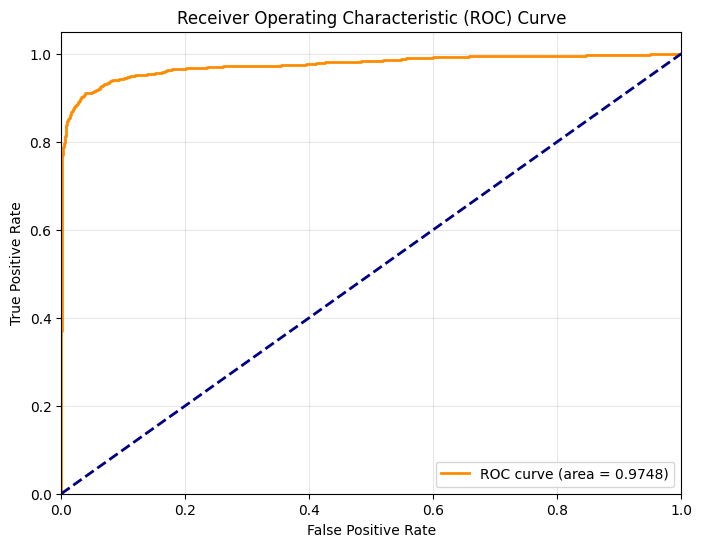

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 1. Load the model with custom objects
print('Loading model...')
model_path = '/content/drive/MyDrive/model utilities/fdcsnet_v4_final.keras'

# safe_mode=False allows deserialization of Lambda layers
model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        'preprocess_fn': preprocess_fn,
        'l2_norm_fn': l2_norm_fn,
        'stack_fn': stack_fn,
        'expand_dims_fn': expand_dims_fn,
        'cast_fn': cast_fn,
        'weighted_sum_fn': weighted_sum_fn,
        'compute_color_stability_map': compute_color_stability_map,
        'compute_fft_magnitude_map': compute_fft_magnitude_map
    },
    safe_mode=False
)

# 2. Re-build test dataset (all supported extensions, matching training pipeline)
print('Preparing test data...')
test_paths, test_labels = [], []
for class_idx, class_name in enumerate(['real', 'ai']):
    class_path = os.path.join(TEST_DIR, class_name)
    if os.path.exists(class_path):
        for fname in sorted(os.listdir(class_path)):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                test_paths.append(os.path.join(class_path, fname))
                test_labels.append(float(class_idx))

test_ds = tf.data.Dataset.from_tensor_slices((np.array(test_paths), np.array(test_labels, dtype=np.float32)))
test_ds = test_ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Threshold: reuse the value selected on the VALIDATION set during
#    training-time evaluation (optimal_threshold). Do NOT re-select it here
#    on the test set — that would leak test information into the decision
#    boundary. If running this cell standalone (fresh runtime), set
#    optimal_threshold manually from configs/config.py CLASSIFICATION_THRESHOLD.
if 'optimal_threshold' not in dir():
    optimal_threshold = 0.8117  # fallback: keep in sync with configs/config.py

# 4. Inference on TEST set
print('Running inference...')
all_preds, all_labels = [], []
for images, labels in test_ds:
    outputs = model(images, training=False)
    preds = outputs[0] if isinstance(outputs, list) else outputs
    all_preds.extend(preds.numpy().flatten())
    all_labels.extend(labels.numpy().flatten())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 5. Metrics (threshold applied, not re-derived, on test set)
y_pred_binary = (all_preds >= optimal_threshold).astype(int)

print('\n' + '='*30)
print(f'Threshold used (from validation): {optimal_threshold:.4f}')
print(f'AUC-ROC: {roc_auc_score(all_labels, all_preds):.4f}')
print('\n--- Classification Report ---')
print(classification_report(all_labels.astype(int), y_pred_binary, target_names=['Real', 'AI']))
print('\n--- Confusion Matrix ---')
print(confusion_matrix(all_labels.astype(int), y_pred_binary))
print('='*30)


📂 Loading model...
📊 Preparing test data...
🧪 Running inference...

Optimal Threshold: 0.8114
AUC-ROC: 0.9748

--- Classification Report ---
              precision    recall  f1-score   support

        Real       0.93      0.96      0.94      1218
          AI       0.95      0.91      0.93      1000

    accuracy                           0.94      2218
   macro avg       0.94      0.94      0.94      2218
weighted avg       0.94      0.94      0.94      2218


--- Confusion Matrix ---
[[1170   48]
 [  90  910]]


In [ ]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(all_labels.astype(int), y_pred_binary)
print(f'Test Accuracy: {test_accuracy:.4%}')
print(f'Correctly Classified: {np.sum(all_labels.astype(int) == y_pred_binary)} / {len(all_labels)}')

Test Accuracy: 93.7782%
Correctly Classified: 2080 / 2218
